### Business problem:  
Vesta Corporation is a global protection and payment solutions company specializing in telecom and mobile commerce.  
It provides a dataset for online e-commerce transactions and the goal is to predict probability of transaction to be fraudulent.  
 
Source - Kaggle IEEE-CIS Fraud detection https://www.kaggle.com/competitions/ieee-fraud-detection  


Key points:  
- failing to detect fraud activity leads to capital loss (chargebacks, fines, lost transaction money) and reputational demage,  
- too aggresive fraud controls increase false positive rejections (checking legitimate customers) and degrading revenue.  
  
The goal: minimize skipped fraud transactions, while maintaining legitimate customers undisrupted. 
Analyse expected losses / saved money for the merchant, Vesta's client. 

### Data description  
  
#### Transactions Table

The transaction dataset captures behavioral, payment, and network-level attributes. Because raw customer identifiers are masked for privacy, features are partitioned into structured domain groups:

| Feature / Group | Type | Description |
| :--- | :--- | :--- |
| **`TransactionDT`** | Numeric (Integer) | Monotonically increasing timedelta (in seconds) from an undisclosed reference datetime. |
| **`TransactionAmt`** | Numeric (Float) | Transaction payment amount in USD. |
| **`ProductCD`** | Categorical | Discrete code representing the product or service category of the purchase. |
| **`card1` – `card6`** | Categorical / Numeric | Payment card metadata (e.g., Bank Identification Number [BIN], card network/brand, card tier, issuer country). |
| **`addr1`, `addr2`** | Categorical (Masked) | Geographic billing and delivery regions (e.g., zip/postal code clusters, regional area codes). |
| **`dist1`, `dist2`** | Numeric (Continuous) | Approximate physical distance (e.g., billing address vs. shipping address, or billing address vs. transaction IP). |
| **`P_emaildomain`<br>`R_emaildomain`** | Categorical | Email domain of the purchaser (`P_`) and recipient (`R_`). |
| **`C1` – `C14`** | Numeric (Discrete Counts) | Masked counting features (e.g., frequency of phone numbers, emails, or cards tied to an account). |
| **`D1` – `D15`** | Numeric (Timedelta Days) | Relative time deltas representing days since prior events (e.g., days since card activation, days since last order). |
| **`M1` – `M9`** | Categorical (Boolean/Match) | Match verification flags comparing names, billing addresses, and delivery recipients. |
| **`V1` – `V339`** | Numeric (Engineered) | Rich relational and entity features engineered by Vesta (rankings, co-occurrence frequencies, aggregation ratios). |

---

####  Identity Table

| Feature / Group | Type | Description |
| :--- | :--- | :--- |
| **`TransactionID`** | Numeric (Integer) | Primary key linking identity metadata back to the `Transactions` table. |
| **`id_01` – `id_11`** | Numeric (Continuous) | Numerical device signals (e.g., screen dimensions, resolution ratios, proxy/VPN ping times, battery/OS hardware offsets). |
| **`id_12`** | Categorical | Indicator denoting whether proxy or IP masking software was detected (`NotFound` vs. `Found`). |
| **`id_13` – `id_14`** | Numeric / Categorical | Network connection attributes, IP port categories, and client-side time-zone offsets. |
| **`id_15` – `id_16`** | Categorical | Browser status indicators (e.g., incognito/private mode detection, authorization session continuity). |
| **`id_17` – `id_22`** | Categorical / Numeric | Extended device and network configurations (ISP routing signatures, connection types, SIM/cellular attributes). |
| **`id_23`** | Categorical | IP proxy level categorization (e.g., `IP_PROXY:TRANSPARENT`, `IP_PROXY:ANONYMOUS`, `IP_PROXY:HIDDEN`). |
| **`id_24` – `id_26`** | Numeric | Telemetry consistency indicators measuring hardware-to-network match confidence. |
| **`id_27` – `id_29`** | Categorical | Account and authorization verification states (`NotFound` vs. `Found`). |
| **`id_30`** | Categorical | Operating system name and version (e.g., `iOS 11.1.2`, `Windows 10`, `Android 7.0`, `Mac OS X`). |
| **`id_31`** | Categorical | Client browser name and engine release (e.g., `chrome 63.0`, `mobile safari 11.0`, `firefox 57.0`, `edge 16.0`). |
| **`id_32`** | Numeric | Screen color bit-depth (e.g., `24`, `32`, `16`). |
| **`id_33`** | Categorical | Display resolution string formatted as width by height (e.g., `1920x1080`, `2208x1242`, `1366x768`). |
| **`id_34`** | Categorical | Match indicator between declared device OS and detected browser user-agent string. |
| **`id_35` – `id_38`** | Categorical (Boolean) | Client security and environment flags (`T` / `F`) verifying cookies, JavaScript execution, and login status. |
| **`DeviceType`** | Categorical | High-level client hardware classification (`desktop`, `mobile`). |
| **`DeviceInfo`** | Categorical | Raw device build model or hardware manufacturer string (e.g., `SM-G935F`, `iOS Device`, `Windows`, `Trident/7.0`). |  

They are collected by Vesta’s fraud protection system and digital security partners.   
(The field names are masked and pairwise dictionary will not be provided for privacy protection and contract agreement).

### Key metrics  
Metrics: ROC-AUC and PR-AUC for imbalanced datasets.  
- ROC-AUC looks at all data (True Positive Rate and False Positive Rate): It measures how well the model ranks fraud higher than legitimate transactions across the whole dataset, but because 96.5% of transactions are legitimate, it can look artificially high (0.90+) even when the model makes thousands of false alarms.  
- PR-AUC focuses strictly on the fraud (Presicion and Recall): It checks only whether the transactions flagged as fraud are actually fraud (Precision) and how many total fraudsters were caught (Recall), making it a much stricter, realistic metric for rare fraud events.

### EDA insights from the data  
  
1. Severe target imbalance  
Training dataset has 3.5% fraudulent transactions, requiring metrics like PR-AUC or ROC-AUC rather than raw accuracy.  

2. Time-split structure 
TransactionDT (time of transaction) is continuous chronological time, which makes random k-fold validation leak future information. Validating strictly with time-series splits or group-based temporal folds is mandatory to mirror real test performance.  

3. Fraud is not stationary over time  
The overall fraud rate fluctuates between ~2.5% and ~4.8%. Some weeks have low fraud rates, and some weeks have fraud spikes. It is worth to investigate further the reasons of this behaviour.  

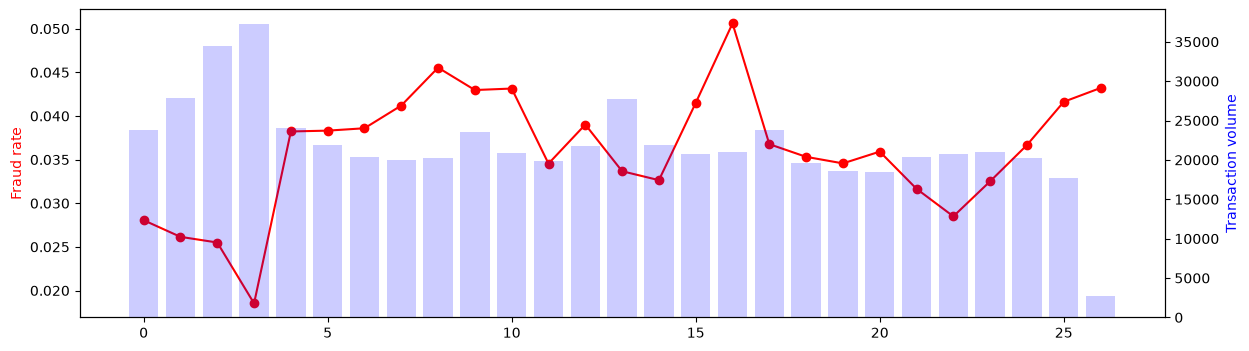  

4. User ID reconstruction  
Fraud rarely occurs in vacuums, so it is important to analyse not just transactions itself, but users making them. This dataset due to privacy protection lacks user account identifiers, so it is important to reconstruct a pseudo ID by combining identity fields (card metadata, address, email domain etc.). Without constructing UIDs, models treat linked fraudulent bursts as independent events. With it, we will be able to measure user-level cumulative and rolling spend, velocity, etc.  
> $$\text{Pseudo\_UID} = \text{card1} \parallel \text{card2} \parallel \text{card3} \parallel \text{card4} \parallel \text{card5} \parallel \text{card6} \parallel \text{addr1} \parallel \text{email domain} \parallel \text{Card birthday}$$

5. Rolling statistics for 24h time window per user  
Analysing online transactions fraud, classic behaviotal signature is sudden fraud spikes and deviations from average 24h transaction frequency of users. To track this behaviour, features were calculated by grouping chronological transactions by the user's pseudoID using 24h time window.   

6. Missingness in V-Features is informative  
V-features were captured from own Vesta systems. It was noticed that these features have identical null patterns, that correspond to specific logging systems of Vesta.  
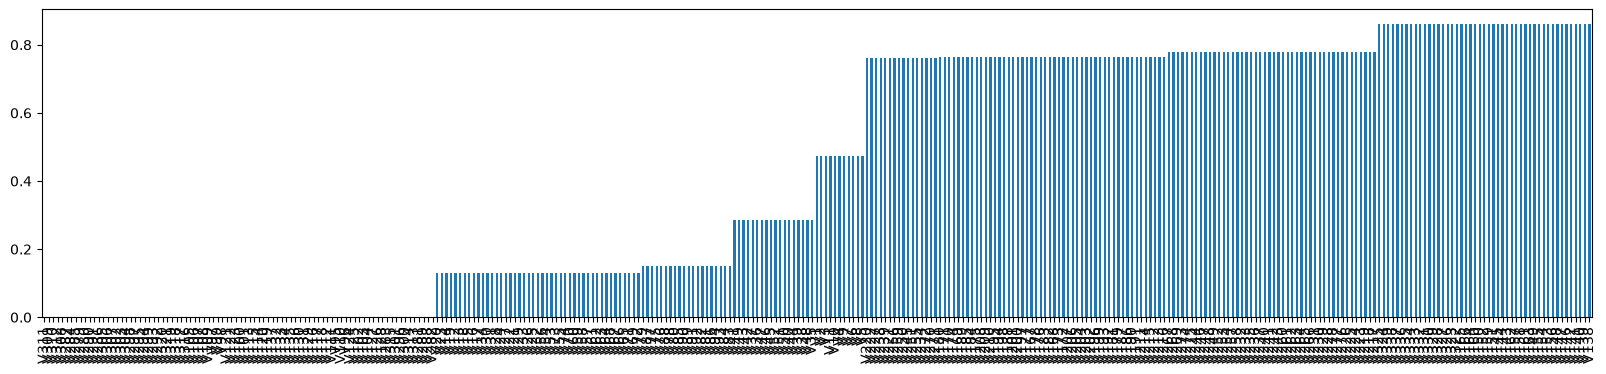  

This lead to the following decisions:  
- cluster V-features by missingness blocks  
- reduce number of features that are collinear inside each missingness block (drop >90% correlated features)   
- analyse whether these clusters have presence/missingness across types of products and payment systems. If yes - keep this flag to help the model avoid the noise/overfit and understand that some V-features are empty just because for some product types they do not exist.    
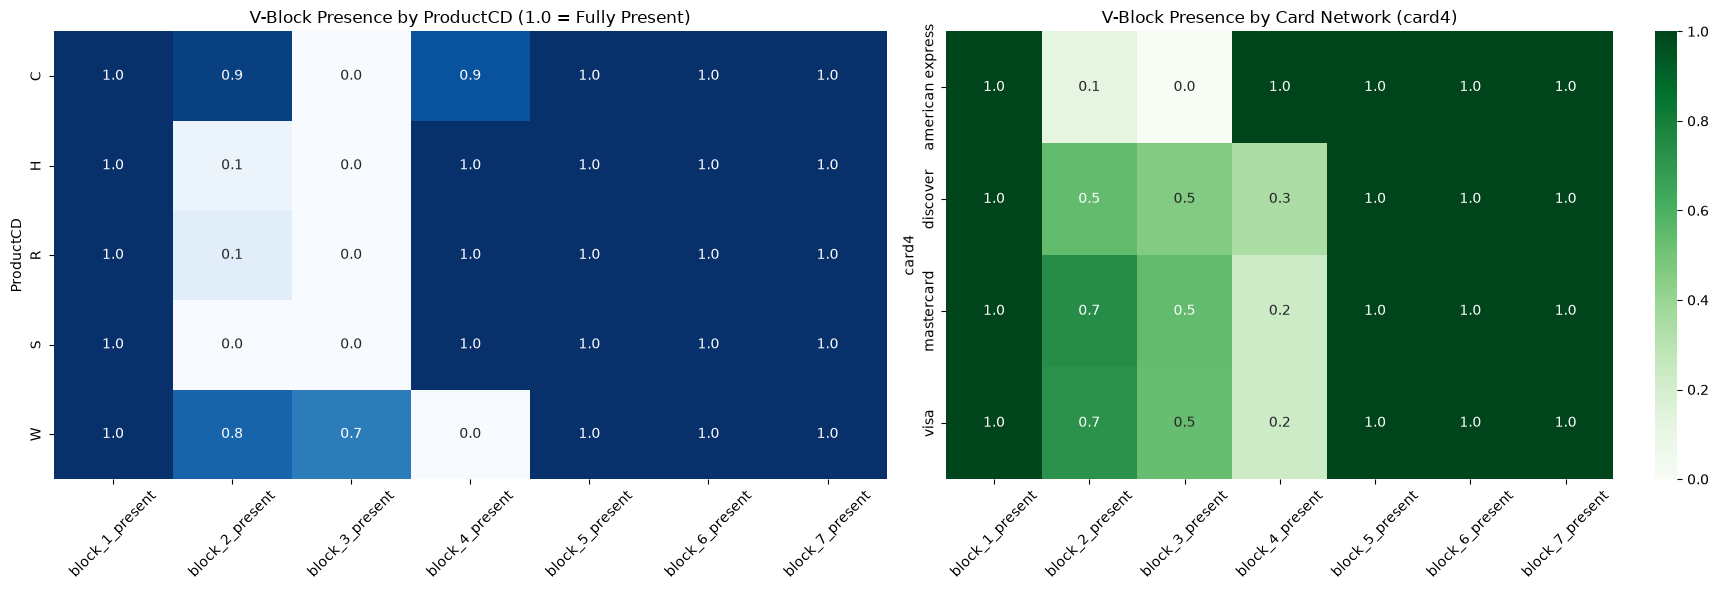  

-  W uses a fundamentally different payment processing pipeline compared to H, R, and S.  
- Amex bypasses traditional 3rd-party banking verification checks that Visa and Mastercard go through.



### Machine learning pipeline structure  

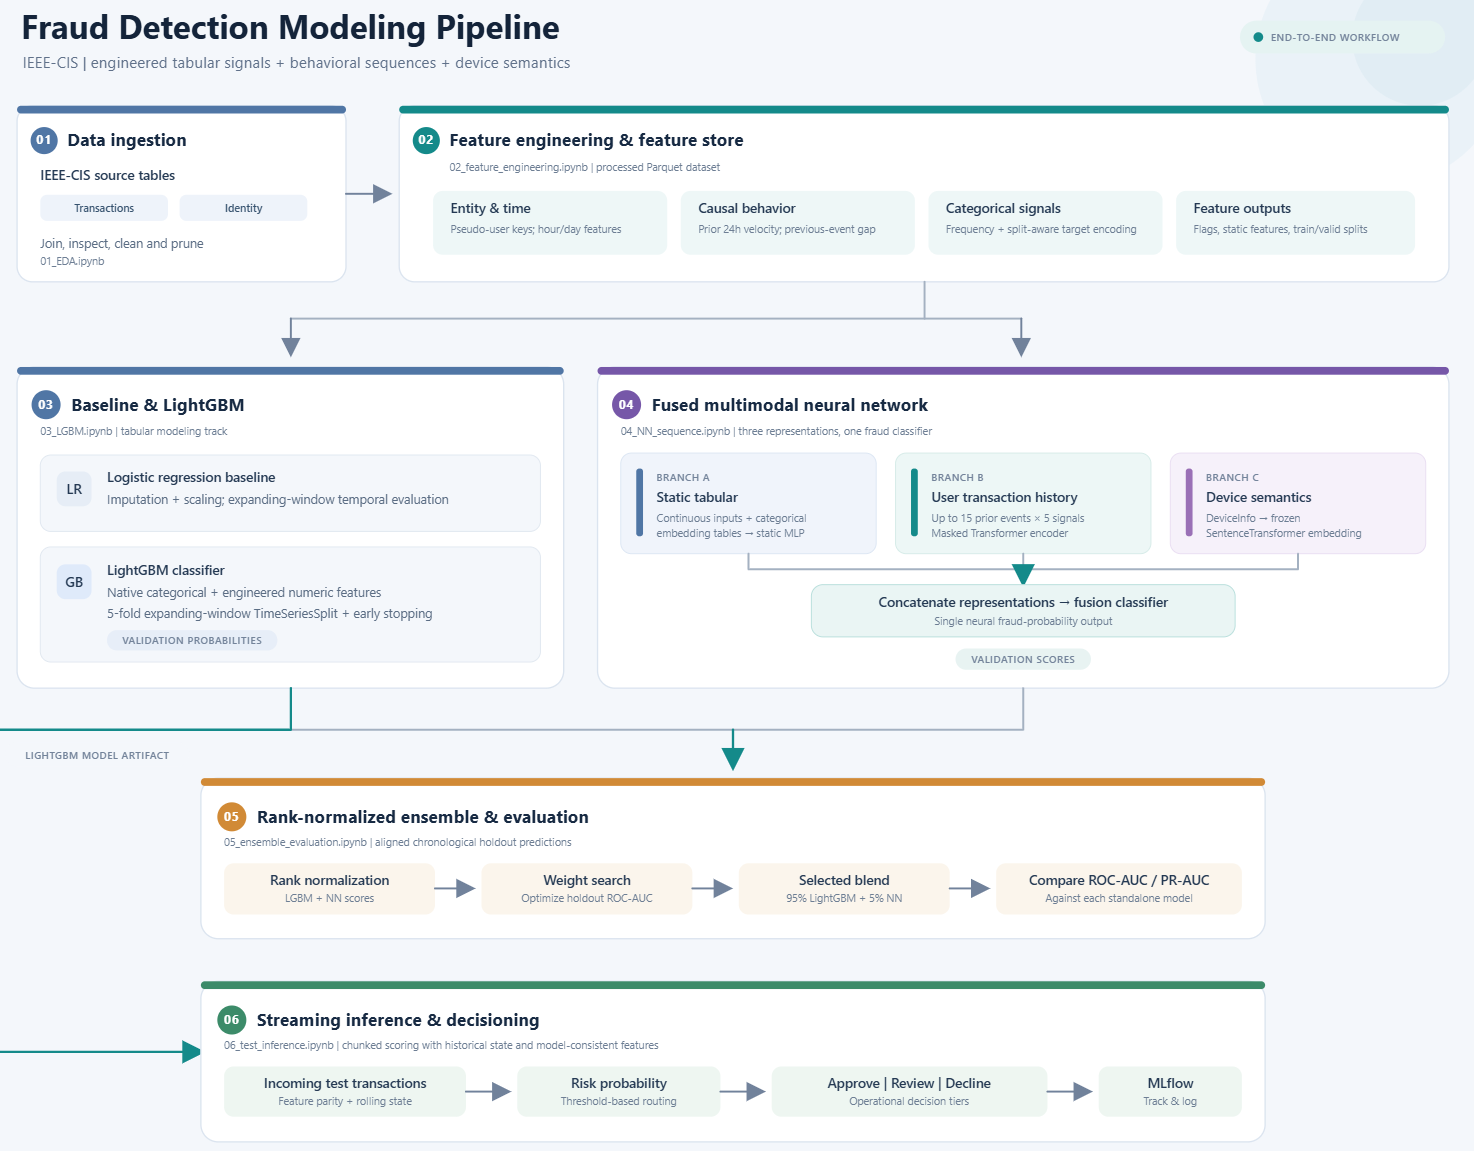

### Training results  



| Model / evaluation | ROC-AUC | PR-AUC |
|---|---:|---:|
| Logistic regression — expanding-window  | 0.82788 | 0.39200 |
| LightGBM — expanding-window  | 0.91670 | 0.59896 |
| LightGBM — chronological 80/20 | 0.94272 | 0.66854 |
| Neural network — chronological 80/20 | 0.88958 | 0.50286 |
| Rank blend (95% LightGBM / 5% NN) — chronological 80/20 | 0.94293 | 0.66185 |

#### Takeways: 
- The ensebmle increased ROC-AUC only by 0.00021 over LightGBM alone, while LightGBM alone retained the higher PR-AUC.  
- Thus, NN is not making significant impact, rather adds noise.  
NNs fail here because sequence models need repeat transactions that rarely exist in this dataset. LightGBM bypasses this cold-start issue entirely by evaluating cards through overall frequency counts and historical group risk rather than individual user histories.  
Also, 590k training transactions is not enough for NNs, expecially having only 3,5% of positive class. 
- Final model selection - LightGBM.


### SHAP analysis (features with the most influence on a decision)  

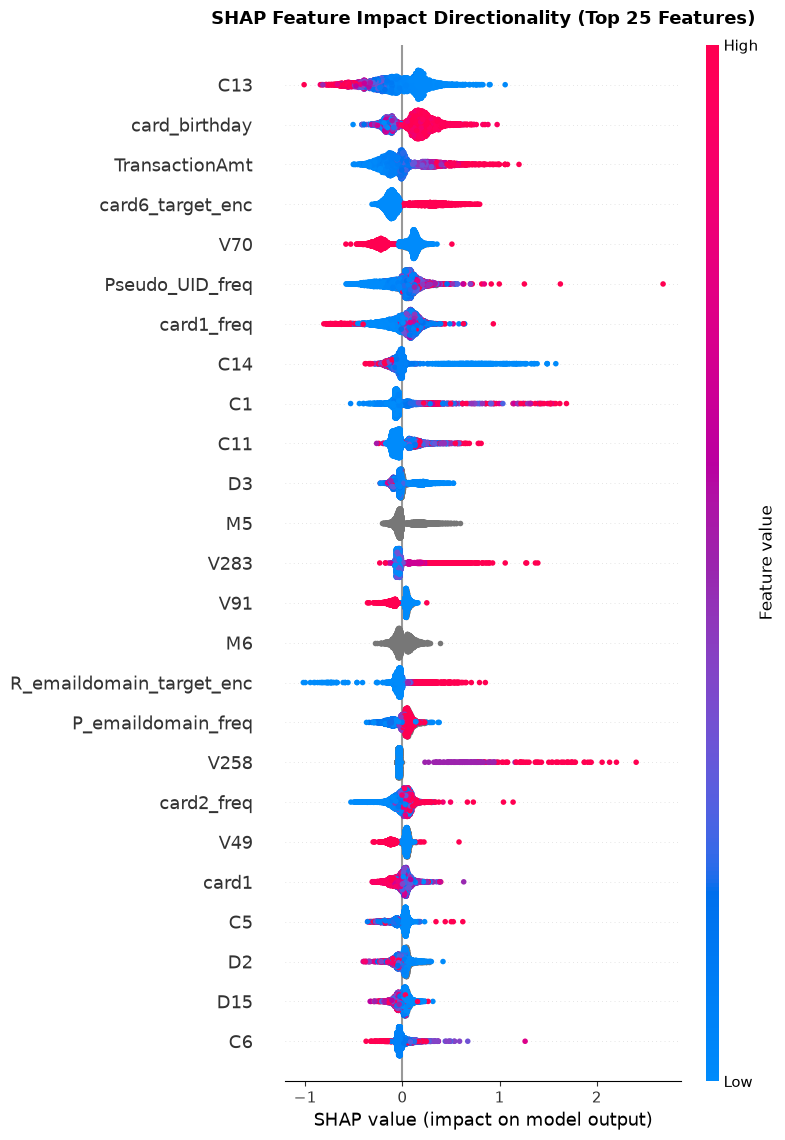  

- velocity and activity counters (C features) influence a decision - high counts push predictions toward fraud.  
- higher transaction amounts increase fraud probability.  
- engineered features (card birthday, pseudo ID frequency, card vendor frequency) prove its effectiveness: newer cards correlate with risk, low frequencies result in negative SHAP values (model does not automatically flag fraud just because user is not frequent).  
- some V features are triggers for fraud risk.  
- target encodings show that high historical fraud rates for particular category increase fraud risk for the transaction.

### Inference logic and business metrics analysis  

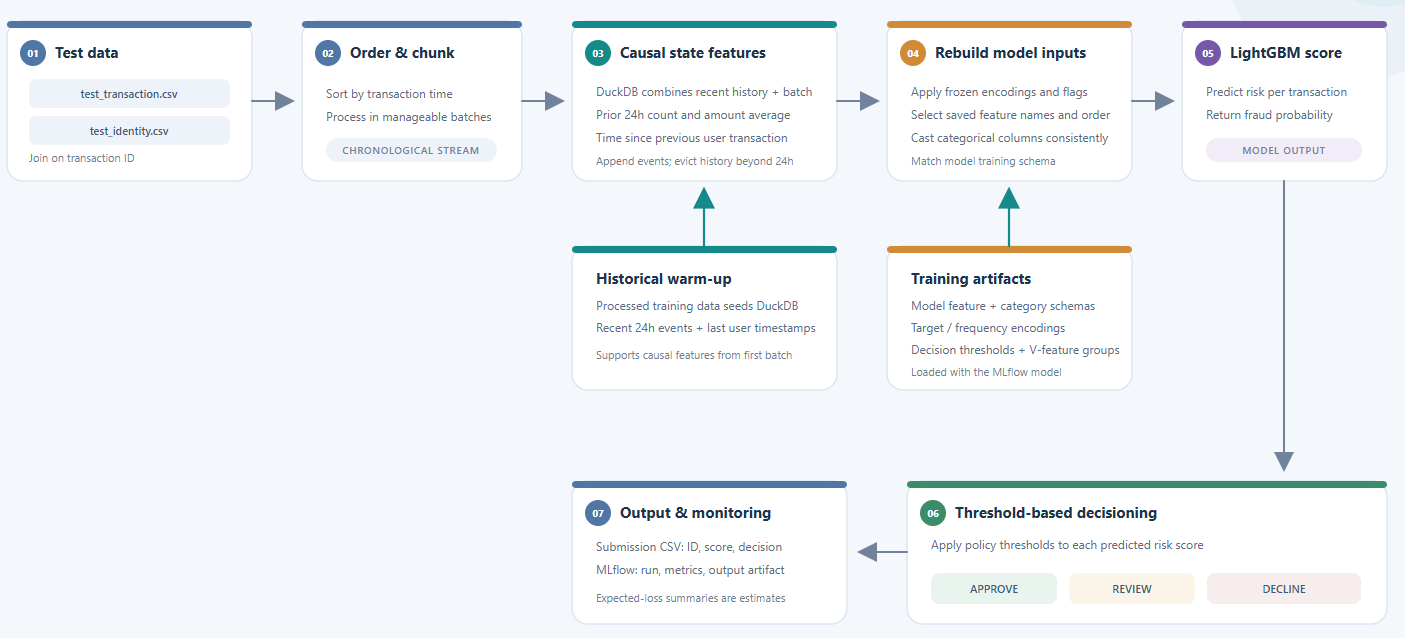

- Raw model probabilities are translated into 3-tier action framework (Approve, Review, Decline) based on current thresholds: 0.05 for reviewing and 0.35 for declining.  
- Additional business metrics are introduced: $2.50 - cost per manual audit of the transaction, $15 - chargeback fee (in case of skipped fraudulent transaction).

### Business impact based on cost-sensitive Bayes decision theory  

Action is to be taken only if its expected cost is strictly lower than the expected cost of the alternatives.  

3-action cost equations:  

1. Cost if auto-approved:  

$$E[\text{Cost}_{\text{Approve}}] = p \cdot (A + \text{Fee}_{\text{cb}})$$

  *(If it's fraud, we lose the amount plus chargeback fee; if legitimate, cost is €0).*

2. Cost if auto-declined:  

$$E[\text{Cost}_{\text{Decline}}] = (1 - p) \cdot \text{Cost}_{\text{churn}}$$

  *(If legitimate, we insult a customer and lose lifetime value; if fraud, cost is €0).*


3. Cost if sent to manual review:  

$$E[\text{Cost}_{\text{Review}}] = C_{\text{audit}} + p \cdot (1 - \text{CatchRate}_{\text{human}}) \cdot (A + \text{Fee}_{\text{cb}})$$

  *(We always pay $C_{\text{review}} \approx \text{€2.50}$ to inspect, plus residual fraud if the human reviewer misses it).*  

  Business rule:  $$if  (A + \text{Fee}_{\text{cb}}) \le C_{\text{audit},}$$ bypass manual review and route directly to Auto-Approve or Auto-Decline whichever is cheaper.  




## Executive summary of business impact  
Test set spans approximately 6 months, chronologically after the training datset.  

Instead of relying on an arbitrary $0.5$ classification threshold or static heuristic cutoffs, decisions are governed by **Cost-Sensitive Bayes Decision Theory**.  
The model assigns one of three operational actions ($\text{Approve}$, $\text{Review}$, $\text{Decline}$) to minimize total realized portfolio cost:

$$\min_{T_{\text{approve}}, T_{\text{decline}}} \sum_{i} \Big( E[\text{Cost}_{\text{Approve}}] + E[\text{Cost}_{\text{Review}}] + E[\text{Cost}_{\text{Decline}}] \Big)$$

#### 1. Economic constraints 
* **Manual Review OpEx ($C_{\text{audit}}$):** €2.50 / ticket | **Human Recall:** 90%
* **Chargeback Fee ($\text{Fee}_{\text{cb}}$):** €15.00 / incident | **Customer Insult / Churn Cost:** €10.00
* **Breakeven Gating Rule:** When $(A + \text{Fee}_{\text{cb}}) \le C_{\text{audit}}$, manual review is bypassed because inspecting costs more than the total exposure. Transactions are routed directly to Approve or Decline based on expected loss.

#### 2. Decision performance on inference

| Metric |  Cost-optimized policy ($T \in [0.0386, 0.2431]$) | Business interpretation |
| :--- |  :--- | :--- |
| **Auto-Approve Rate** | **84.57%** (428,509 txns) | Preserves revenue |
| **Manual Review Rate** |  **12.10%** (61,318 txns) | Queue capacity control & staffing budget |
| **Hard Decline Rate** |  **3.33%** (16,864 txns) | Fraud mitigation |
| **Gross Prevented Loss** |  **€1,576,806.88** | Chargeback capital and dispute fees preserved |
| **Review Queue OpEx** |  **€153,295.00** | Direct manual review labor incurred |
| **Policy ROI** | **€10.29 saved / €1 spent** | Capital saved per €1.00 of review labor |

#### Key takeaways
1. **Capital protection efficiency:** Hard declining 3.33% of total transactions (16,864 txns) eliminates **€1,576,806.88** in gross fraud exposure, yielding an average capital savings of **€93.50 per automated decline**.
2. **Operational leverage:** The manual review absorbs 12.10% of total volume (61,318 txns) at an operational cost of **€153,295.00**, delivering a policy return of **€10.29 saved per €1.00 spent** on investigation labor.
3. **Review constraint:** Business rule on a manual review costs keep transactions away from manual review, ensuring audit resources are deployed only where potential fraud loss exceeds the inspection cost.